# Loan Prediction using ML

Smart Lender — Applicant Credit-worthiness Prediction

## Importing the Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
import sklearn

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
import imblearn
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


## Read the Dataset

In [2]:
# importing the dataset which is in csv file
data = pd.read_csv('../Dataset/loan_prediction.csv')
data.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,No,3+,Graduate,NaN,8907,3089,82.0,60.0,NaN,Urban,Y
1,LP001002,Female,No,0,Graduate,No,12862,4188,123.0,180.0,1.0,Semiurban,Y
2,LP001003,Male,Yes,2,Not Graduate,No,9889,861,96.0,180.0,1.0,Semiurban,Y
3,LP001004,Male,Yes,0,Graduate,No,6605,2001,169.0,180.0,1.0,Urban,Y
4,LP001005,Male,No,0,Graduate,No,7712,2053,87.0,360.0,1.0,Semiurban,Y


In [3]:
data.shape


(614, 13)

## Univariate Analysis

<Axes: title={'center': 'Applicant Income distribution'}, ylabel='Frequency'>

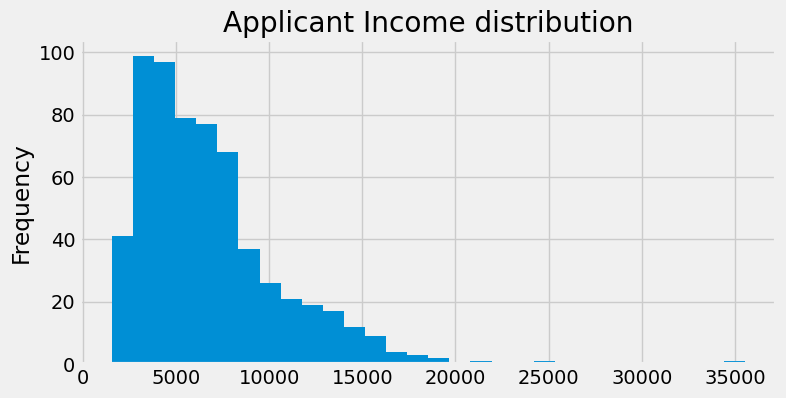

In [4]:
data['ApplicantIncome'].plot.hist(bins=30, figsize=(8,4), title='Applicant Income distribution')


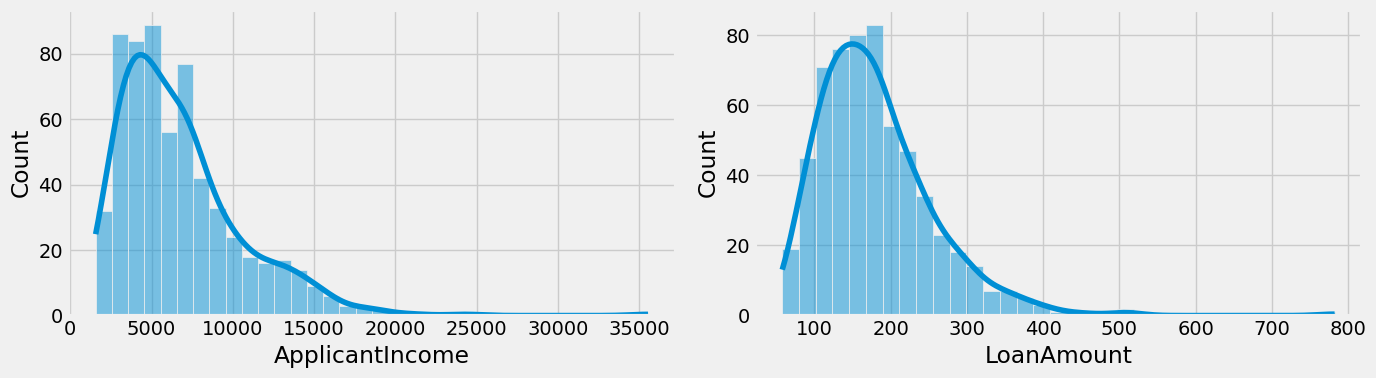

In [5]:
# Distplot for continuous variables
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data['ApplicantIncome'], kde=True, ax=axes[0])
sns.histplot(data['LoanAmount'].dropna(), kde=True, ax=axes[1])
plt.tight_layout()


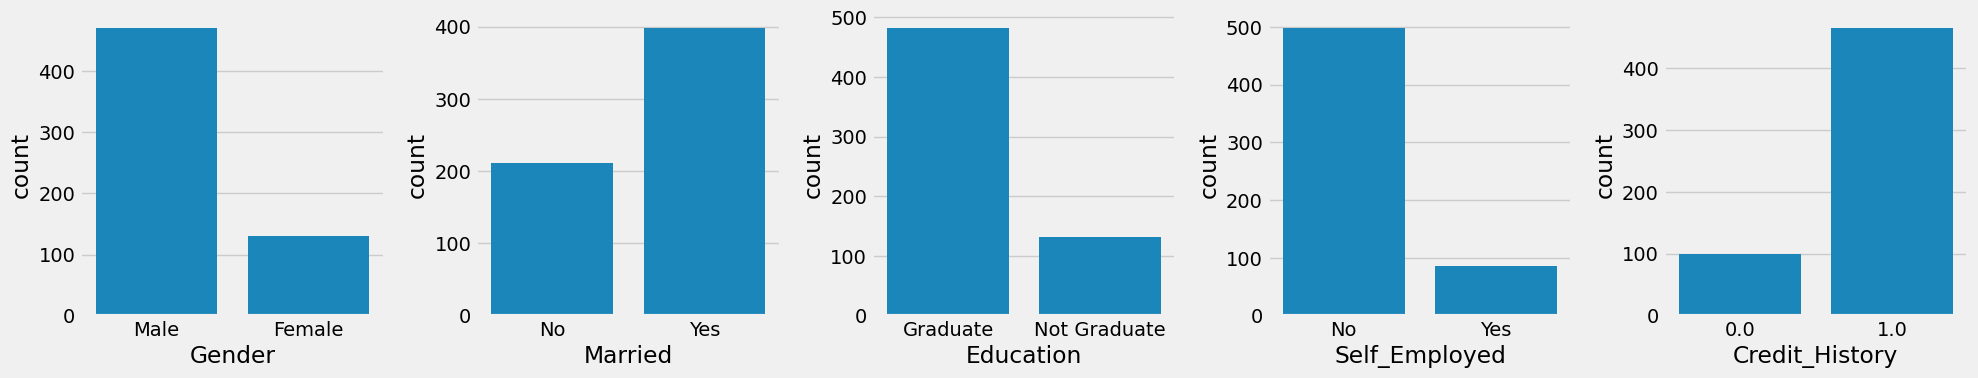

In [6]:
# Countplot for categorical features
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Credit_History']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 4))
for i, col in enumerate(cat_cols):
    sns.countplot(x=data[col], ax=axes[i])
plt.tight_layout()


**Observations:**
- Applicant income exhibits a right/left-skewed distribution.
- Credit history is a binary feature with values 0 and 1.
- Gender and education are categorical variables with two categories each.


## Bivariate Analysis

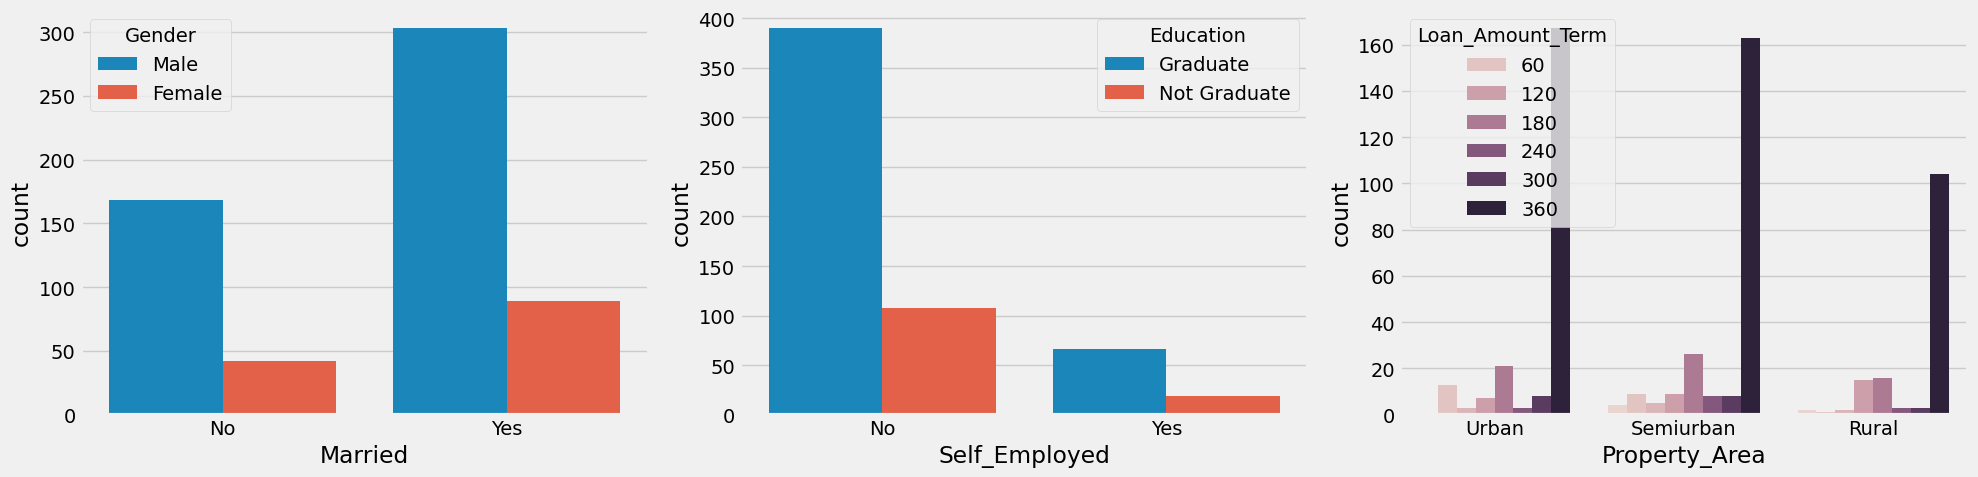

In [7]:
# visualising two columns against each other
plt.figure(figsize=(20,5))
plt.subplot(131)
sns.countplot(x=data['Married'], hue=data['Gender'])
plt.subplot(132)
sns.countplot(x=data['Self_Employed'], hue=data['Education'])
plt.subplot(133)
sns.countplot(x=data['Property_Area'], hue=data['Loan_Amount_Term'])
plt.tight_layout()


## Multivariate Analysis

<Axes: xlabel='Gender', ylabel='ApplicantIncome'>

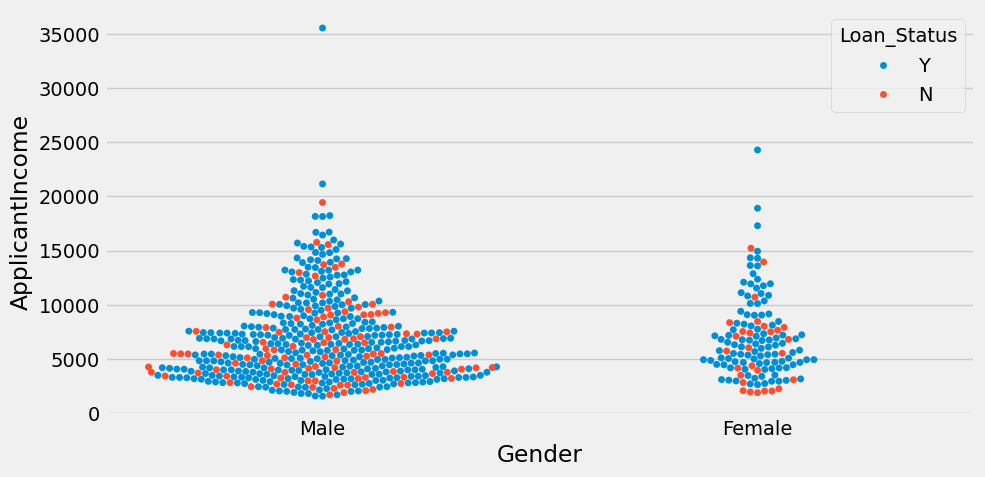

In [8]:
# visualized based on gender and income what would be the application status
plt.figure(figsize=(10,5))
sns.swarmplot(x=data['Gender'], y=data['ApplicantIncome'], hue=data['Loan_Status'])


## Checking and Handling Values

In [9]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             602 non-null    str    
 2   Married            609 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      583 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    int64  
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(3), int64(2), str(8)
memory usage: 62.5 KB


In [10]:
data.isnull().sum()


Loan_ID               0
Gender               12
Married               5
Dependents           15
Education             0
Self_Employed        31
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
# Handling missing values
# numerical -> mean, categorical -> mode
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    data[col] = data[col].fillna(data[col].mean())

for col in ['Gender', 'Married', 'Dependents', 'Self_Employed']:
    data[col] = data[col].fillna(data[col].mode()[0])

data.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [12]:
# Handling categorical values
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
data['Dependents'] = data['Dependents'].replace('3+', 3).astype(int)
data['Education'] = data['Education'].map({'Graduate': 1, 'Not Graduate': 0})
data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 0})
data['Property_Area'] = data['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})
data['Loan_Status'] = data['Loan_Status'].map({'Y': 1, 'N': 0})
data.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,1,0,3,1,0,8907,3089,82.0,60.0,0.824468,2,1
1,LP001002,0,0,0,1,0,12862,4188,123.0,180.0,1.000000,1,1
2,LP001003,1,1,2,0,0,9889,861,96.0,180.0,1.000000,1,1
3,LP001004,1,1,0,1,0,6605,2001,169.0,180.0,1.000000,2,1
4,LP001005,1,0,0,1,0,7712,2053,87.0,360.0,1.000000,1,1


In [13]:
x = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']
x.shape, y.shape


((614, 11), (614,))

## Balancing the Dataset

In [14]:
# balancing the imbalanced dataset using SMOTE
smote = SMOTE()
x_bal, y_bal = smote.fit_resample(x, y)
print(y.value_counts())
print(y_bal.value_counts())
names = x_bal.columns


Loan_Status
1    480
0    134
Name: count, dtype: int64
Loan_Status
1    480
0    480
Name: count, dtype: int64


## Scaling the Data

In [15]:
# performing feature scaling operation using standard scaler on x part of the dataset
# because it has a wide range of values in the columns
sc = StandardScaler()
x_bal = sc.fit_transform(x_bal)
x_bal = pd.DataFrame(x_bal, columns=names)
x_bal.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.625543,-1.190855,2.606485,0.717074,-0.323602,0.658477,0.726026,-1.396959,-2.696588,0.411953,1.351825
1,-1.598611,-1.190855,-0.706259,0.717074,-0.323602,1.754278,1.279613,-0.834807,-1.373989,0.812024,0.043607
2,0.625543,0.839733,1.502237,-1.394556,-0.323602,0.930557,-0.396259,-1.205004,-1.373989,0.812024,0.043607
3,0.625543,0.839733,-0.706259,0.717074,-0.323602,0.020668,0.177981,-0.204099,-1.373989,0.812024,1.351825
4,0.625543,-1.190855,-0.706259,0.717074,-0.323602,0.327382,0.204174,-1.328404,0.609909,0.812024,0.043607


## Splitting Data into Training and Test Sets

In [16]:
# splitting the dataset into train and test on balanced dataset
X_train, X_test, y_train, y_test = train_test_split(
    x_bal, y_bal, test_size=0.33, random_state=42)
X_train.shape, X_test.shape


((643, 11), (317, 11))

## Decision Tree Model

In [17]:
# importing and building the Decision tree model
def decisionTree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred, y_test))
    print(confusion_matrix(y_test, yPred))
    print(classification_report(y_test, yPred))
    return model

# printing the train accuracy and test accuracy respectively
dt_model = decisionTree(X_train, X_test, y_train, y_test)


1.0
0.8801261829652997
[[140  14]
 [ 24 139]]
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       154
           1       0.91      0.85      0.88       163

    accuracy                           0.88       317
   macro avg       0.88      0.88      0.88       317
weighted avg       0.88      0.88      0.88       317



## Random Forest Model

In [18]:
# importing and building the random forest model
def RandomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred, y_test))
    print(confusion_matrix(y_test, yPred))
    print(classification_report(y_test, yPred))
    return model

# printing the train accuracy and test accuracy respectively
rf_model = RandomForest(X_train, X_test, y_train, y_test)


1.0


0.9274447949526814
[[143  11]
 [ 12 151]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       154
           1       0.93      0.93      0.93       163

    accuracy                           0.93       317
   macro avg       0.93      0.93      0.93       317
weighted avg       0.93      0.93      0.93       317



## KNN Model

In [19]:
# importing and building the KNN model
def KNN(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred, y_test))
    print(confusion_matrix(y_test, yPred))
    print(classification_report(y_test, yPred))
    return model

# printing the train accuracy and test accuracy respectively
knn_model = KNN(X_train, X_test, y_train, y_test)


0.9051321928460342
0.8769716088328076
[[134  20]
 [ 19 144]]
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       154
           1       0.88      0.88      0.88       163

    accuracy                           0.88       317
   macro avg       0.88      0.88      0.88       317
weighted avg       0.88      0.88      0.88       317



## XGBoost Model

In [20]:
# importing and building the xg boost model
def XGB(X_train, X_test, y_train, y_test):
    model = GradientBoostingClassifier()
    model.fit(X_train, y_train)
    y_tr = model.predict(X_train)
    print(accuracy_score(y_tr, y_train))
    yPred = model.predict(X_test)
    print(accuracy_score(yPred, y_test))
    print(confusion_matrix(y_test, yPred))
    print(classification_report(y_test, yPred))
    return model

# printing the train accuracy and test accuracy respectively
xgb_model = XGB(X_train, X_test, y_train, y_test)


0.9720062208398134
0.9211356466876972
[[141  13]
 [ 12 151]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       154
           1       0.92      0.93      0.92       163

    accuracy                           0.92       317
   macro avg       0.92      0.92      0.92       317
weighted avg       0.92      0.92      0.92       317



## Evaluating Performance and Saving the Model

In [21]:
# cross validation to verify consistent model performance across different data splits
models = {'DecisionTree': dt_model, 'RandomForest': rf_model, 'KNN': knn_model, 'XGB': xgb_model}
cv_scores = {}
for name, m in models.items():
    scores = cross_val_score(m, x_bal, y_bal, cv=5)
    cv_scores[name] = scores.mean()
    print(f"{name}: CV accuracy = {scores.mean():.4f}")

best_name = max(cv_scores, key=cv_scores.get)
model = models[best_name]
print(f"\nBest model selected: {best_name}")


DecisionTree: CV accuracy = 0.8802


RandomForest: CV accuracy = 0.9240
KNN: CV accuracy = 0.8740


XGB: CV accuracy = 0.9198

Best model selected: RandomForest


In [22]:
# saving the model by using pickle function
pickle.dump(model, open('rdf.pkl', 'wb'))
pickle.dump(sc, open('scale1.pkl', 'wb'))
print("Saved rdf.pkl and scale1.pkl")


Saved rdf.pkl and scale1.pkl
